Taille des caractéristiques (features) : (166315, 10)
Taille des étiquettes (labels) : (166315, 1)


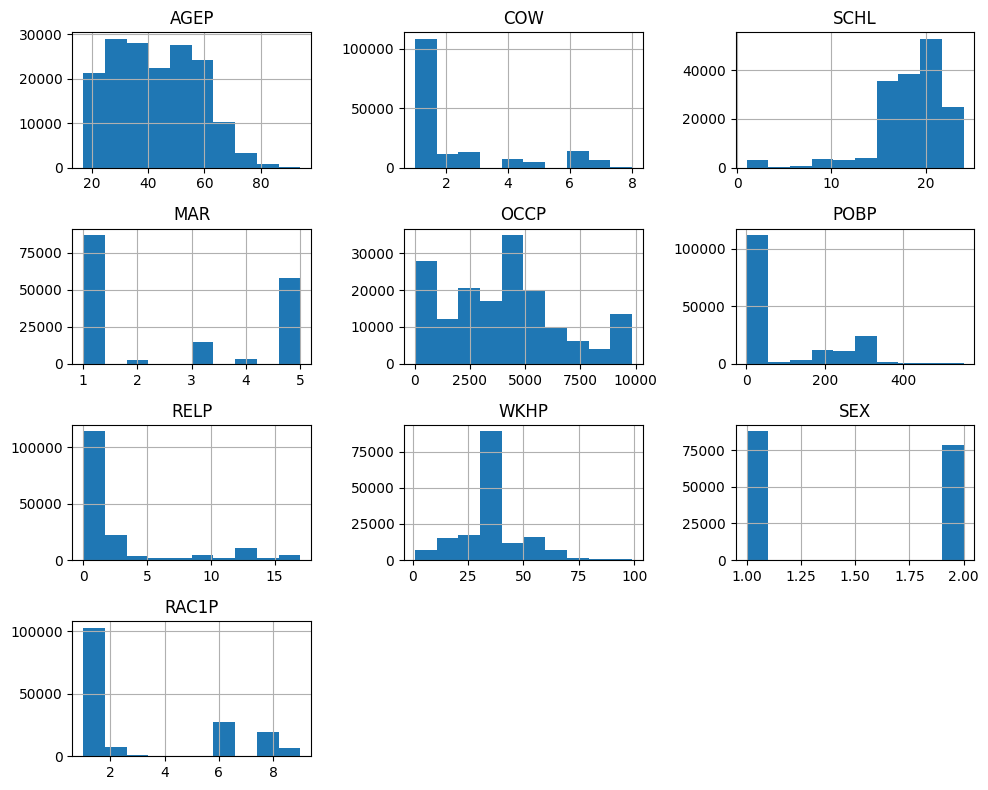

Taille de X_train : (133052, 10)
Taille de X_test : (33263, 10)


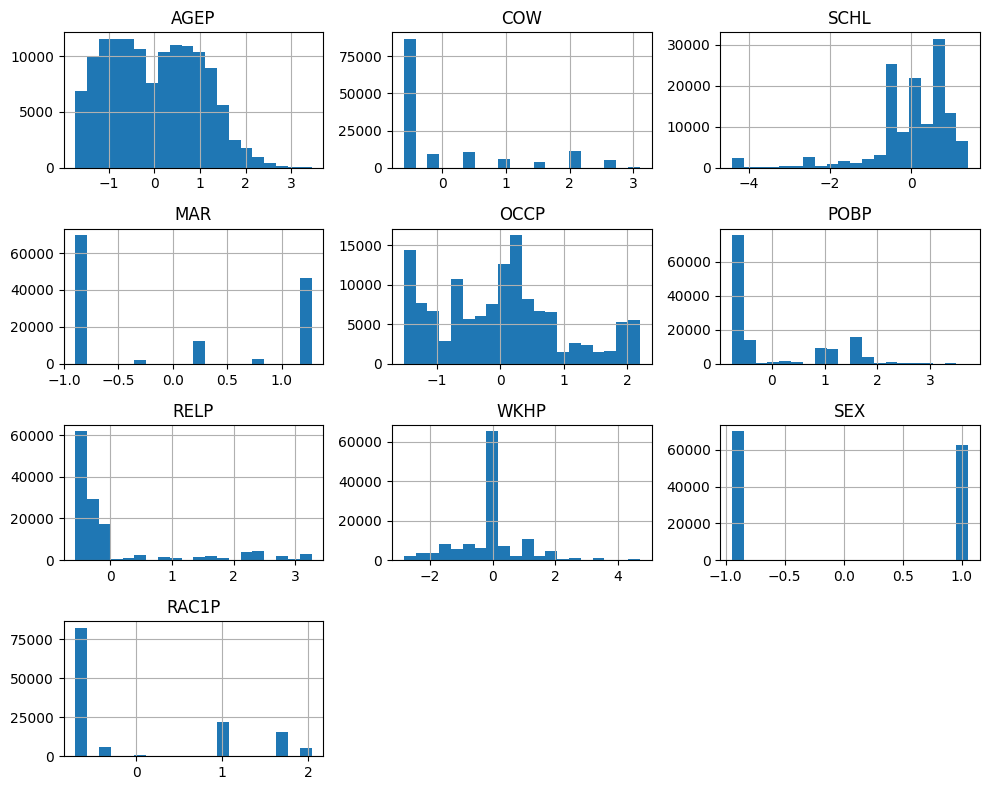

In [3]:
#Elkhatiri Walid
#Fofana Elhaji Bafodé 
#COmpréhension jeu de donées
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import sklearn.model_selection as skmodel
from sklearn import preprocessing
import joblib
#path=""

name="alt_acsincome_ca_features_85(1).csv"





#Q1
features_file = "alt_acsincome_ca_features_85(1).csv"
labels_file = "alt_acsincome_ca_labels_85.csv"

df_feat = pd.read_csv(features_file)
df_lab = pd.read_csv(labels_file)
print(f"Taille des caractéristiques (features) : {df_feat.shape}")
print(f"Taille des étiquettes (labels) : {df_lab.shape}")

df_feat.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

#Q2
X_train, X_test, y_train, y_test = skmodel.train_test_split(
    df_feat, df_lab, test_size=0.2, shuffle=True, random_state=42
)

print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test : {X_test.shape}")

#Q3/Q4
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.joblib')

scaler_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
scaler_df.hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.metrics import accuracy_score, classification_report


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train.values.ravel())  # Rendre y_train compatible
# n_estimators=100, max_depth=4, min_samples_split= 2, min_samples_leaf=2,


y_pred = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle : {accuracy:.2f}")

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

importances = rf_model.feature_importances_
for feature, importance in zip(df_feat.columns, importances):
    print(f"{feature}: {importance:.4f}")

Précision du modèle : 0.82

Rapport de classification :
              precision    recall  f1-score   support

       False       0.84      0.85      0.84     19594
        True       0.78      0.77      0.77     13669

    accuracy                           0.82     33263
   macro avg       0.81      0.81      0.81     33263
weighted avg       0.82      0.82      0.82     33263


Matrice de confusion :
[[16676  2918]
 [ 3210 10459]]
AGEP: 0.1710
COW: 0.0432
SCHL: 0.1278
MAR: 0.0317
OCCP: 0.2680
POBP: 0.0854
RELP: 0.0812
WKHP: 0.1382
SEX: 0.0212
RAC1P: 0.0323


In [5]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

adaboost = AdaBoostClassifier()
adaboost.fit(X_train_scaled, y_train.values.ravel())
y_pred = adaboost.predict(X_test_scaled)
print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\n Class Stats :")
print(classification_report(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy:.2f}")


c:\Users\walid\Desktop\5A\app_supervise\tp-supervise\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Matrice de confusion :
[[16492  3102]
 [ 3248 10421]]

 Class Stats :
              precision    recall  f1-score   support

       False       0.84      0.84      0.84     19594
        True       0.77      0.76      0.77     13669

    accuracy                           0.81     33263
   macro avg       0.80      0.80      0.80     33263
weighted avg       0.81      0.81      0.81     33263


Accuracy : 0.81


In [6]:

from sklearn.ensemble import  GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_scaled, y_train.values.ravel())
y_pred_gb = gb_model.predict(X_test_scaled)

print("\nMatrice de confusion (Gradient Boosting) :")
print(confusion_matrix(y_test, y_pred_gb))

print("\nRapport de classification (Gradient Boosting) :")
print(classification_report(y_test, y_pred_gb))

accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"\nPrécision globale (Accuracy - Gradient Boosting) : {accuracy_gb:.2f}")



Matrice de confusion (Gradient Boosting) :
[[16653  2941]
 [ 3262 10407]]

Rapport de classification (Gradient Boosting) :
              precision    recall  f1-score   support

       False       0.84      0.85      0.84     19594
        True       0.78      0.76      0.77     13669

    accuracy                           0.81     33263
   macro avg       0.81      0.81      0.81     33263
weighted avg       0.81      0.81      0.81     33263


Précision globale (Accuracy - Gradient Boosting) : 0.81


In [ ]:
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

param_rf = {
    'n_estimators': [100, 150, 175, 200, 250],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [8, 10, 12, 15],
    'min_samples_leaf': [4, 5, 6, 7]
}


rf_model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_rf, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train.values.ravel())

print("\nMeilleurs paramètres (Random Forest) :")
print(grid_search.best_params_)

print("\nMeilleur score (Random Forest) :")
print(grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)

print("\nMatrice de confusion (Random Forest) :")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRapport de classification (Random Forest) :")
print(classification_report(y_test, y_pred_rf))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nPrécision globale (Accuracy - Random Forest) : {accuracy_rf:.4f}")

# Enregistrement du modèle avec l'accuracy dans le nom du fichier
filename = f'RandomForest_BestModel_Accuracy_{accuracy_rf:.4f}.joblib'
joblib.dump(grid_search.best_estimator_, filename)

param_ada = {
    'n_estimators': [25, 50, 75,100, 125,150, 200],
    'learning_rate': [0.01, 0.02, 0.5,0.1, 0.15, 0.2,0.25],
    'algorithm': ['SAMME', 'SAMME.R']
}

ada_model = AdaBoostClassifier()
grid_search_ada = GridSearchCV(estimator=ada_model, param_grid=param_ada, cv=5, scoring='accuracy')
grid_search_ada.fit(X_train_scaled, y_train.values.ravel())

print("\nMeilleurs paramètres (AdaBoost) :")
print(grid_search_ada.best_params_)

print("\nMeilleur score (AdaBoost) :")
print(grid_search_ada.best_score_)

best_ada_model = grid_search_ada.best_estimator_
y_pred_ada = best_ada_model.predict(X_test_scaled)

print("\nMatrice de confusion (AdaBoost) :")
print(confusion_matrix(y_test, y_pred_ada))

print("\nRapport de classification (AdaBoost) :")
print(classification_report(y_test, y_pred_ada))

accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"\nPrécision globale (Accuracy - AdaBoost) : {accuracy_ada:.4f}")

filename = f'AdaBoost_BestModel_Accuracy_{accuracy_ada:.4f}.joblib'
joblib.dump(grid_search_ada.best_estimator_, filename)

param_gb = {
    'n_estimators': [50, 100, 125,150, 200],
    'learning_rate': [0.01, 0.1, 0.15, 0.2, 0.5],
    'max_depth': [3, 5, 10, 7,15],
    'subsample': [0.8, 0.9, 1.0, 0.5,1.5]
}

gb_model = GradientBoostingClassifier()

grid_search_gb = GridSearchCV(estimator=gb_model, param_grid=param_gb, cv=5, scoring='accuracy')
grid_search_gb.fit(X_train_scaled, y_train.values.ravel())

print("\nMeilleurs paramètres (Gradient Boosting) :")
print(grid_search_gb.best_params_)

print("\nMeilleur score (Gradient Boosting) :")
print(grid_search_gb.best_score_)

best_gb_model = grid_search_gb.best_estimator_

y_pred_gb = best_gb_model.predict(X_test_scaled)

print("\nMatrice de confusion (Gradient Boosting) :")
print(confusion_matrix(y_test, y_pred_gb))

print("\nRapport de classification (Gradient Boosting) :")
print(classification_report(y_test, y_pred_gb))

accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"\nPrécision globale (Accuracy - Gradient Boosting) : {accuracy_gb:.4f}")

filename = f'GradientBoosting_BestModel_Accuracy_{accuracy_gb:.4f}.joblib'
joblib.dump(grid_search_gb.best_estimator_, filename)



c:\Users\walid\Desktop\5A\app_supervise\tp-supervise\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
2730 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\walid\Desktop\5A\app_supervise\tp-supervise\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\walid\Desktop\5A\app_supervise\tp-supervise\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\walid\Desktop\5A\app_supervise\tp-supervise\Lib\site-packages\sklearn\base.py",


Meilleurs paramètres (Random Forest) :
{'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 150}

Meilleur score (Random Forest) :
0.8206941353096008

Matrice de confusion (Random Forest) :
[[16758  2836]
 [ 3122 10547]]

Rapport de classification (Random Forest) :
              precision    recall  f1-score   support

       False       0.84      0.86      0.85     19594
        True       0.79      0.77      0.78     13669

    accuracy                           0.82     33263
   macro avg       0.82      0.81      0.81     33263
weighted avg       0.82      0.82      0.82     33263


Précision globale (Accuracy - Random Forest) : 0.8209
